🏠 Project Overview: House Price Prediction
The goal of this project is to build a machine learning model that predicts the selling price of a house based on its characteristics (like area size, number of bedrooms, and whether it has air conditioning).

You implemented Linear Regression, which is a fundamental statistical method that finds the "line of best fit" between your input features and the house price.

Import Libraries and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning specific tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Load and Explore the Data

In [ ]:
# Load your dataset (assuming a local file or URL)
df = pd.read_csv('Housing.csv')

# Look at the first 5 rows
print("--- First 5 Rows ---")
print(df.head())

# Check data types and look for missing values
print("\n--- Data Info ---")
print(df.info())

--- First 5 Rows ---
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entri

Data Cleaning & Preprocessing

In [ ]:
# 1. Fill missing numerical values with the median of that column
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# 2. Convert text columns (Categorical) to numbers using One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

Split Features and Target Variable

In [ ]:
# Separate the target variable (price) from the feature attributes
X = df.drop(columns=['price'])
y = df['price']

# Split the dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total number of features after encoding: {X.shape[1]}")
print(f"Training set size: {X_train.shape[0]} houses")
print(f"Testing set size: {X_test.shape[0]} houses")

Total number of features after encoding: 13
Training set size: 436 houses
Testing set size: 109 houses


Model Training

In [ ]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


Model Evaluation

In [ ]:
# Generate price predictions for the test dataset
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R²) Score: {r2:.4f}")

--- Model Performance Metrics ---
Mean Squared Error (MSE): 1,754,318,687,330.66
Root Mean Squared Error (RMSE): $1,324,506.96
R-squared (R²) Score: 0.6529


Visualization

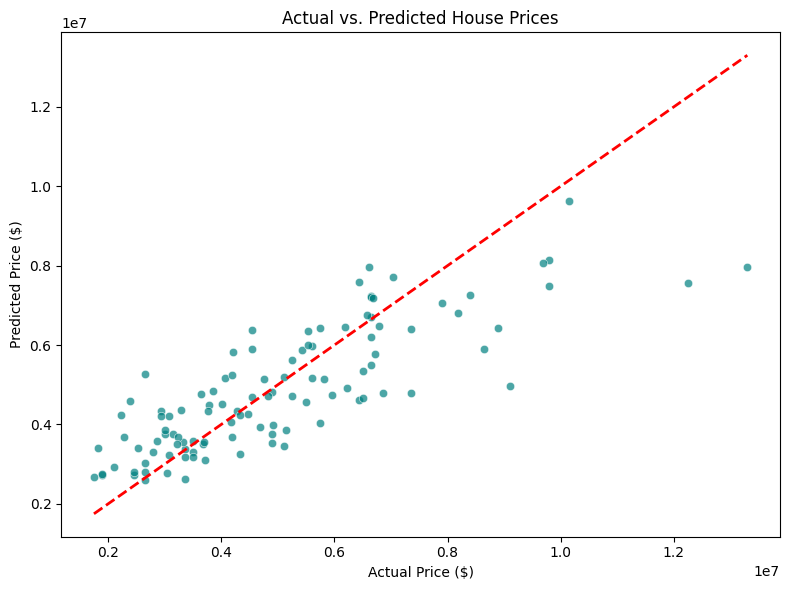

In [ ]:
# Plot Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='teal')

# Draw a red diagonal reference line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs. Predicted House Prices")
plt.tight_layout()
plt.show()

🌍 Real-World Uses of this Project
While you are using this model specifically for housing data, the exact same Linear Regression pipeline you just built is used across dozens of industries:

Real Estate & Appraisal: Platforms like Zillow or Redfin use expanded versions of this exact model to instantly estimate property values (Zestimates) for millions of homes.

Retail & E-commerce Price Optimization: Companies use it to predict the optimal price for a new product based on its features (brand, material, size) to maximize profit.

Financial Forecasting: Banks and investors use linear regression to estimate future stock prices, asset values, or economic growth trends.

Marketing ROI: Businesses use it to predict total sales revenue based on how much money they spend on different advertising channels (TV, Social Media, Radio).